# 04 PSM 策略验证（核心）：把外呼渠道统一改为手机，是否因果性提升了转化率？

## 业务问题

01/02 已建立的事实：first_time（新客）组渠道差异显著（cellular 11.7% vs telephone 4.7%，Cramér's V=0.1219），returning 组不显著（V=0.0108，p=0.42）。本 notebook 回答：

1. **朴素比较**（手机组 vs 座机组转化率之差）里有多少是"渠道本身的差异"、多少是"客群构成的差异"（选择偏差）？
2. 用倾向得分匹配（PSM）剥离可观测选择偏差后，**"经可观测因素调整后的效应估计"**是多少？置信区间如何？
3. 这个结论在**两种不同匹配规格**（标准 caliper-最近邻 / 精确匹配月份+层内匹配）下是否稳健？
4. 回归客（returning）能不能做同样的分析？——按 00 文档 §2.5，做受限的鲁棒性尝试，**以匹配质量为门**。

> 本 notebook 是**观察性数据下的因果推断**核心。全程遵守 00 文档："结论是**经可观测因素调整后的效应估计**，不是因果效应"——未观测混杂（销售现场为何选择某一渠道等）的局限在文末显式声明。

## 口径与五条硬约束宣读（00 文档 §2.7，开工前定案，代码中逐条自检）

| # | 约束 | 来源 | 本 notebook 落地方式 |
|---|---|---|---|
| 1 | **PSM 作用域** | §2.5 | **主分析限定 first_time（新客）**；returning 不进入主分析，仅作受限鲁棒性尝试、以匹配质量为门（不达标则仅描述性提及朴素差异+局限） |
| 2 | **混杂变量清单** | §2.6 | 时间代理**只用 `month`**；五个宏观变量（euribor3m/emp.var.rate/nr.employed/cons.price.idx/cons.conf.idx）**不进倾向得分模型**（assert 自检） |
| 3 | **pdays 口径** | §2.3 + 01 | first_time 组内 `pdays` 恒为 999（无变异），不作为混杂变量（代码记录该事实，assert `nunique==1`）；描述性部分沿用 01 的 `pdays_bucket` 口径 |
| 4 | **campaign 边界** | 00 声明四 | `campaign` **不进处理变量**（处理变量只有 `contact`）、**不进倾向得分模型**（assert 自检）——反向因果变量，见下方"混杂变量选择依据" |
| 5 | **duration 排除** | 00 声明一 | `duration` 不进倾向得分模型（assert 自检） |

**处理变量定义**：`contact_bin = 1`（cellular，手机，处理组）/ `0`（telephone，座机，对照组）。业务问题问的是"**把渠道统一改为手机系**"——因此处理组是手机，估计的是**手机相对座机的效应（ATT，处理组=手机组）**。

**效应对象**：ATT（处理组平均效应）定义在被成功匹配的手机组客户上。本分析中"共同支撑域"检查会显示：相当比例的手机组客户找不到可比座机组（对应月份座机几乎没有被使用），ATT 是**共同支撑域内**（尤其电话渠道仍被使用的月份）的估计——这是本 notebook 最重要的诚实性声明之一。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# 定位项目根目录并加入模块搜索路径（与前序 notebook 相同的启动逻辑）
_CWD = Path.cwd()
_PROBE = Path("src") / "telemarketing_utils.py"
if not (_CWD / _PROBE).exists() and (_CWD.parent / _PROBE).exists():
    sys.path.insert(0, str(_CWD.parent))
else:
    sys.path.insert(0, str(_CWD))

from src.telemarketing_utils import (  # noqa: E402
    find_project_root, setup_plot_style,
    estimate_propensity_score, nearest_neighbor_match, check_balance,
)

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-additional-full.csv"
REPORT_DIR = PROJECT_ROOT / "reports"

setup_plot_style()
import matplotlib.pyplot as plt  # noqa: E402

df = pd.read_csv(DATA_PATH, sep=";")
df["y_bin"] = (df["y"] == "yes").astype(int)
# 五条硬约束 #1：主分析限定 first_time（previous == 0）
ft = df[df["previous"] == 0].copy()
ft["contact_bin"] = (ft["contact"] == "cellular").astype(int)

# 混杂变量清单（方案A 主规格；人口统计 + 联系时点）
NUMERIC_COLS = ["age"]
CATEGORICAL_COLS = ["job", "marital", "education", "default", "housing", "loan",
                    "day_of_week", "month"]

# 五条硬约束自检
assert ft["previous"].nunique() == 1, "first_time 内 previous 恒为 0"
assert ft["pdays"].nunique() == 1, "约束#3：first_time 内 pdays 恒为 999（无变异，不作为混杂）"
assert ft["poutcome"].nunique() == 1, "first_time 内 poutcome 恒为 nonexistent（无变异，不作为混杂）"
MACRO = {"euribor3m", "emp.var.rate", "nr.employed", "cons.price.idx", "cons.conf.idx"}
assert not (set(NUMERIC_COLS + CATEGORICAL_COLS) & MACRO), "约束#2：宏观共线变量不得进模型"
assert "month" in CATEGORICAL_COLS, "约束#2：month 是唯一时间代理"
assert "campaign" not in NUMERIC_COLS + CATEGORICAL_COLS, "约束#4：campaign 不得进倾向得分模型"
assert "duration" not in NUMERIC_COLS + CATEGORICAL_COLS, "约束#5：duration 不得进倾向得分模型"
print("✓ 五条硬约束全部通过（作用域/混杂清单/pdays/campaign/duration）")
print("  first_time 样本:", len(ft), "| 手机组:", int(ft["contact_bin"].sum()),
      "| 座机组:", int((ft["contact_bin"] == 0).sum()))
print("  混杂特征：数值", NUMERIC_COLS, "+ 类别", CATEGORICAL_COLS)

✓ 五条硬约束全部通过（作用域/混杂清单/pdays/campaign/duration）
  first_time 样本: 35563 | 手机组: 20922 | 座机组: 14641
  混杂特征：数值 ['age'] + 类别 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'day_of_week', 'month']


## 第一步：朴素比较——先量化"选择偏差"有多大

朴素比较 = 直接对比两组转化率，**不控制任何客群差异**。它回答"观测到的差距有多大"，但无法区分"渠道效应"与"客群构成差异"。先看全量（含 returning 混入的干扰），再看限定 first_time（本 notebook 的正式作用域）。

In [2]:
# 朴素比较
naive_rows = []
for label, g in [("全量（含回归客）", df), ("限定 first_time（新客）", ft)]:
    cc = g[g["contact"] == "cellular"]["y_bin"]
    tc = g[g["contact"] == "telephone"]["y_bin"]
    diff = cc.mean() - tc.mean()
    naive_rows.append({"口径": label, "手机组转化率": round(cc.mean(), 4),
                       "手机组n": len(cc), "座机组转化率": round(tc.mean(), 4),
                       "座机组n": len(tc), "差距(pp)": round(diff * 100, 2)})
naive_tab = pd.DataFrame(naive_rows)
naive_tab

# 月份 x 渠道构成（共同支撑域叙事的关键：哪些月份几乎没有座机组）
mc = pd.crosstab(ft["month"], ft["contact_bin"])
mc.columns = ["telephone", "cellular"]
mc["cellular占比%"] = (mc["cellular"] / (mc["cellular"] + mc["telephone"]) * 100).round(1)
print("\nfirst_time 月份 x 渠道构成：")
print(mc.to_string())


first_time 月份 x 渠道构成：
       telephone  cellular  cellular占比%
month                                  
apr          149      1725         92.0
aug          236      5483         95.9
dec           25        73         74.5
jul         1053      5893         84.8
jun         4476       527         10.5
mar           39       328         89.4
may         8117      3643         31.0
nov          354      2743         88.6
oct          129       285         68.8
sep           63       222         77.9


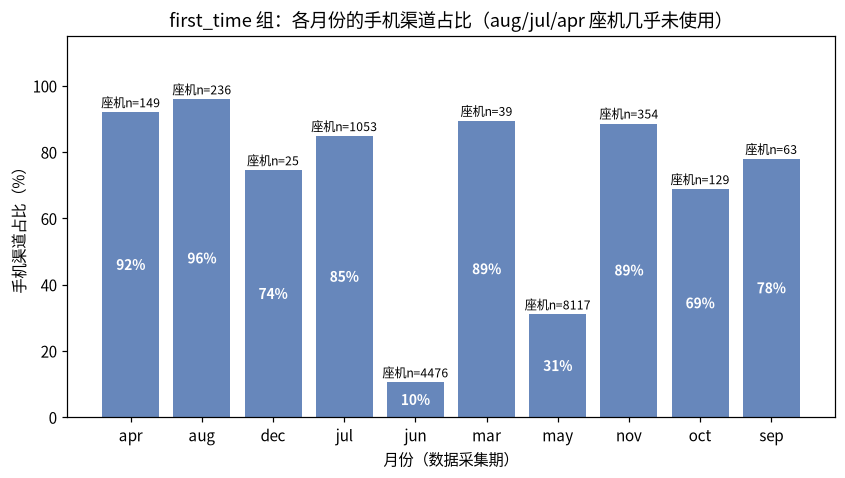

In [3]:
# 月份构成可视化：电话渠道（座机）渗透率随月份剧烈变化
fig, ax = plt.subplots(figsize=(9, 4.5))
months = mc.index.tolist()
shares = mc["cellular占比%"].values
bars = ax.bar(months, shares, color="#4C72B0", alpha=0.85)
for b, s, t in zip(bars, shares, mc["telephone"]):
    ax.text(b.get_x() + b.get_width() / 2, s + 1.5, f"座机n={t}", ha="center", fontsize=8)
    ax.text(b.get_x() + b.get_width() / 2, s / 2, f"{s:.0f}%", ha="center",
            va="center", color="white", fontsize=9, fontweight="bold")
ax.set_ylabel("手机渠道占比（%）")
ax.set_xlabel("月份（数据采集期）")
ax.set_title("first_time 组：各月份的手机渠道占比（aug/jul/apr 座机几乎未使用）")
ax.set_ylim(0, 115)
plt.savefig(REPORT_DIR / "04_month_channel_share.png", bbox_inches="tight")
plt.show()

## 第二步：混杂变量选择依据（PSM 报告四件套之一）

**候选 → 入选/排除全过程**：

| 类别 | 变量 | 是否进倾向得分模型 | 理由 |
|---|---|---|---|
| 人口统计 | `age`、`job`、`marital`、`education`、`default`、`housing`、`loan` | ✅ 进 | 影响渠道可得性（座机/手机号存在性）与转化意愿，且**先于渠道分配存在**（00 文档声明三前提 2） |
| 联系时点 | `month` | ✅ 进（唯一时间代理） | 渠道渗透率随月份剧烈变化（上表 10.5%→95.9%），必须控制；宏观连续变量 VIF 63.9/32.9/30.7 共线，一律排除（00 §2.6，assert 已自检） |
| 联系时点 | `day_of_week` | ✅ 进 | 拨打时段安排可能同时影响渠道与接通率 |
| 历史痕迹 | `previous`/`pdays`/`poutcome` | ⛔ 组内常量 | first_time 组内无变异（`previous==0`、`pdays==999`、`poutcome==nonexistent`），不构成混杂——**旅程阶段已通过作用域限定剥离**（这正是 §2.5 分层设计的依据之一） |
| 本次活动 | `campaign` | ⛔ **禁止** | **反向因果 / confounding by indication**：打更多电话是"销售判断有希望"的结果，销售主观判断不可观测；对 campaign 做 PSM 违反条件可交换性（00 声明四）。只做描述性边际分析（notebook 05） |
| 通话信息 | `duration` | ⛔ **禁止** | 数据泄漏：通话时长是结果不是原因（00 声明一） |

**方案A/B 双规格预告**：方案A 用标准单一逻辑回归估计倾向得分（含 month）+ caliper 最近邻匹配——教科书口径；方案B 用"精确匹配 month + 层内匹配"处理方案A 暴露的月份失衡——替换实现思路（敏感性/稳健性验证用）。

In [4]:
# 倾向得分模型（方案A：单一 pooled 逻辑回归，处理组=手机）
ft_ps, ps_model, X_ps, names_ps = estimate_propensity_score(
    ft, "contact_bin", NUMERIC_COLS, CATEGORICAL_COLS, random_state=42)
auc_ps = roc_auc_score(ft_ps["contact_bin"], ft_ps["pscore"])
print(f"倾向得分模型：LogisticRegression，{len(names_ps)} 维（OneHot 后），AUC = {auc_ps:.4f}")
print("（AUC 0.88 说明渠道分配确实强烈依赖可观测特征——选择偏差是真实存在的）")

t_logit = ft_ps.loc[ft_ps["contact_bin"] == 1, "logit_ps"]
c_logit = ft_ps.loc[ft_ps["contact_bin"] == 0, "logit_ps"]
print(f"\nlogit(倾向得分) 分布——共同支撑域检查（方案A）：")
print(f"  手机组:  median {t_logit.median():.2f}, min {t_logit.min():.2f}, max {t_logit.max():.2f}  (n={len(t_logit)})")
print(f"  座机组:  median {c_logit.median():.2f}, min {c_logit.min():.2f}, max {c_logit.max():.2f}  (n={len(c_logit)})")
lo, hi = c_logit.min(), c_logit.max()
in_support = ft_ps[(ft_ps["contact_bin"] == 1) & (ft_ps["logit_ps"] >= lo) & (ft_ps["logit_ps"] <= hi)]
print(f"  手机组落入座机组[logit范围]的比例: {len(in_support)}/{len(t_logit)} = {len(in_support) / len(t_logit):.1%}")
print("  （范围重叠 100% 是粗筛；真正的共同支撑域判断看 caliper 匹配率与月份构成，见下）")

倾向得分模型：LogisticRegression，41 维（OneHot 后），AUC = 0.8825
（AUC 0.88 说明渠道分配确实强烈依赖可观测特征——选择偏差是真实存在的）

logit(倾向得分) 分布——共同支撑域检查（方案A）：
  手机组:  median 2.01, min -3.05, max 4.36  (n=20922)
  座机组:  median -1.01, min -3.39, max 4.41  (n=14641)
  手机组落入座机组[logit范围]的比例: 20922/20922 = 100.0%
  （范围重叠 100% 是粗筛；真正的共同支撑域判断看 caliper 匹配率与月份构成，见下）


已保存 04_common_support_before.png（完整双面板图在匹配后产出 04_common_support.png）


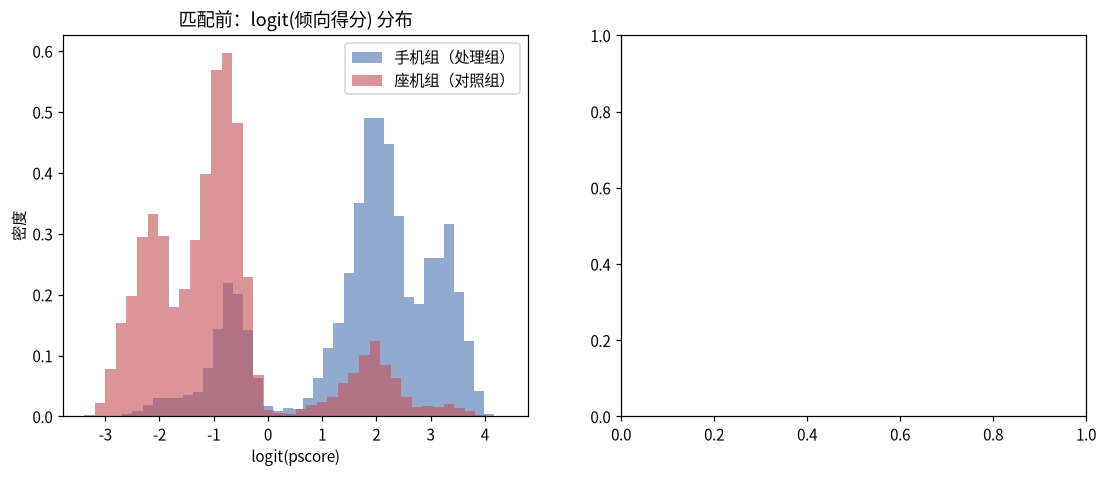

In [5]:
# 共同支撑域可视化（匹配前；匹配后面板在匹配完成后补画）
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(t_logit, bins=40, alpha=0.6, density=True, color="#4C72B0", label="手机组（处理组）")
axes[0].hist(c_logit, bins=40, alpha=0.6, density=True, color="#C44E52", label="座机组（对照组）")
axes[0].set_title("匹配前：logit(倾向得分) 分布")
axes[0].set_xlabel("logit(pscore)"); axes[0].set_ylabel("密度")
axes[0].legend()
plt.savefig(REPORT_DIR / "04_common_support_before.png", bbox_inches="tight")
print("已保存 04_common_support_before.png（完整双面板图在匹配后产出 04_common_support.png）")

## 第三步：最近邻匹配（方案A，主规格）

**规格**：1:1 贪心最近邻、**无放回**、logit 倾向得分距离、caliper = 0.2 × logit 标准差（Rubin 建议口径）。处理组（手机组）按倾向得分从高到低依次匹配其最近的"尚未被匹配过的"座机组；距离超过 caliper 的手机组被丢弃（视为超出共同支撑域）。

**匹配成功率（事先预判）**：月份构成图已经埋下伏笔——aug/jul/apr 座机几乎未使用（占比 84.8%~95.9%），这些月份的手机组**没有可比的座机组可匹配**，大概率被 caliper 丢弃。匹配成功率低本身不是匹配失败，而是**共同支撑域的真实缺口**。

匹配规格摘要：
  caliper = 0.3819（0.2 × logit 标准差）
  匹配对数 = 6259（处理组 20922 人，对照组 14641 人）
  匹配成功率 = 29.9%
  配对 logit 距离：均值 0.1357，最大 0.3819（≈caliper 边界）

匹配样本月份构成：
  apr: 5.9%
  aug: 8.9%
  dec: 0.2%
  jul: 10.1%
  jun: 8.4%
  mar: 0.9%
  may: 58.1%
  nov: 6.2%
  oct: 1.0%
  sep: 0.3%
（全量手机组的月份构成——对比可看出匹配样本高度集中在电话渠道仍被使用的月份）
month
apr     8.2
aug    26.2
dec     0.3
jul    28.2
jun     2.5
mar     1.6
may    17.4
nov    13.1
oct     1.4
sep     1.1


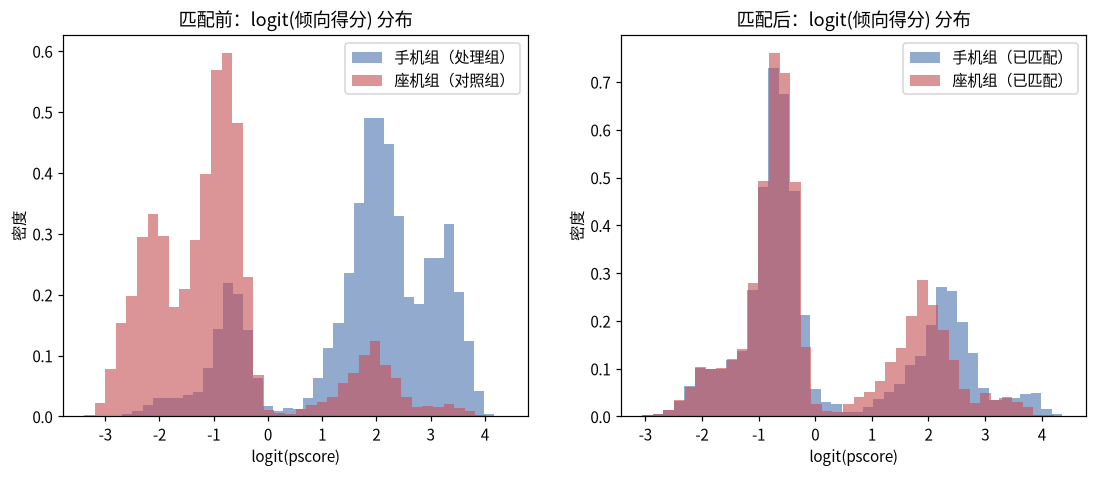

In [6]:
# 方案A：caliper 最近邻匹配
pairsA, metaA = nearest_neighbor_match(ft_ps, "contact_bin", caliper=0.2 * ft_ps["logit_ps"].std())
print("匹配规格摘要：")
print(f"  caliper = {metaA['caliper']:.4f}（0.2 × logit 标准差）")
print(f"  匹配对数 = {metaA['matched_pairs']}（处理组 {metaA['treated']} 人，对照组 {metaA['control']} 人）")
print(f"  匹配成功率 = {metaA['match_rate']:.1%}")
print(f"  配对 logit 距离：均值 {metaA['mean_pair_dist']:.4f}，最大 {metaA['max_pair_dist']:.4f}（≈caliper 边界）")

# 匹配样本的月份构成——ATT 的适用人群画像
comp = pairsA["month"].value_counts(normalize=True).sort_index() * 100
print("\n匹配样本月份构成：")
for m, p in comp.items():
    print(f"  {m}: {p:.1f}%")
print("（全量手机组的月份构成——对比可看出匹配样本高度集中在电话渠道仍被使用的月份）")
print(ft_ps.loc[ft_ps["contact_bin"] == 1, "month"].value_counts(normalize=True).sort_index().mul(100).round(1).to_string())

# 补画共同支撑域完整双面板
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(t_logit, bins=40, alpha=0.6, density=True, color="#4C72B0", label="手机组（处理组）")
axes[0].hist(c_logit, bins=40, alpha=0.6, density=True, color="#C44E52", label="座机组（对照组）")
axes[0].set_title("匹配前：logit(倾向得分) 分布"); axes[0].set_xlabel("logit(pscore)"); axes[0].set_ylabel("密度"); axes[0].legend()
axes[1].hist(pairsA["logit_ps"], bins=40, alpha=0.6, density=True, color="#4C72B0", label="手机组（已匹配）")
axes[1].hist(pairsA["logit_ps_c"], bins=40, alpha=0.6, density=True, color="#C44E52", label="座机组（已匹配）")
axes[1].set_title("匹配后：logit(倾向得分) 分布"); axes[1].set_xlabel("logit(pscore)"); axes[1].set_ylabel("密度"); axes[1].legend()
plt.savefig(REPORT_DIR / "04_common_support.png", bbox_inches="tight")
plt.show()

## 第四步：平衡性检验（SMD）——匹配质量的核心证据（PSM 报告四件套之二）

**标准化均差（Standardized Mean Difference, SMD）**：`|均值差| / sqrt((var_t + var_c) / 2)`，类别变量按每个水平算二值 SMD。约定 **SMD < 0.1 视为平衡**（匹配完成了"两组客户在可观测特征上可比"的目标）。

**匹配后若大部分特征 SMD < 0.1**，则匹配前的组间差异被成功剥离；**若个别特征仍失衡**，需要判断是"匹配失败"还是"共同支撑域缺陷"——两种性质完全不同。

In [7]:
# 把配对小表展开为长表（每行一个个体，标记 _t），用于匹配后的平衡性检验
def make_long(pairs: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    treated_side = pairs[cols].assign(_t=1)
    control_side = pairs[[c + "_c" for c in cols]].rename(columns={c + "_c": c for c in cols}).assign(_t=0)
    return pd.concat([treated_side, control_side], ignore_index=True)

after_long = make_long(pairsA, NUMERIC_COLS + CATEGORICAL_COLS)
ft_ps["_t"] = ft_ps["contact_bin"]
smd_tab = check_balance(ft_ps, after_long, "_t", NUMERIC_COLS, CATEGORICAL_COLS)
smd_tab["类别"] = np.where(smd_tab.index.str.startswith("month_"), "月份", "人口统计/时点")
n_unbalanced = int((smd_tab["匹配后SMD"] > 0.1).sum())
print(f"SMD 检验：共 {len(smd_tab)} 个特征（水平），匹配后 >0.1 的有 {n_unbalanced} 个")
print(smd_tab[smd_tab["匹配后SMD"] > 0.1][["匹配前SMD", "匹配后SMD"]].to_string())
print("\n（未列出的特征=匹配后全部 <0.1，视为平衡）")
print("\n关键特征核对：")
for feat in ["age(数值)", "job_management", "default_no"]:
    r = smd_tab.loc[feat]
    print(f"  {feat}: 匹配前 {r['匹配前SMD']:.4f} → 匹配后 {r['匹配后SMD']:.4f}")

SMD 检验：共 49 个特征（水平），匹配后 >0.1 的有 3 个
           匹配前SMD  匹配后SMD
month_apr  0.3491  0.1785
month_aug  0.7604  0.2112
month_jul  0.5718  0.1980

（未列出的特征=匹配后全部 <0.1，视为平衡）

关键特征核对：
  age(数值): 匹配前 0.0313 → 匹配后 0.0291
  job_management: 匹配前 0.0175 → 匹配后 0.0006
  default_no: 匹配前 0.2474 → 匹配后 0.0061


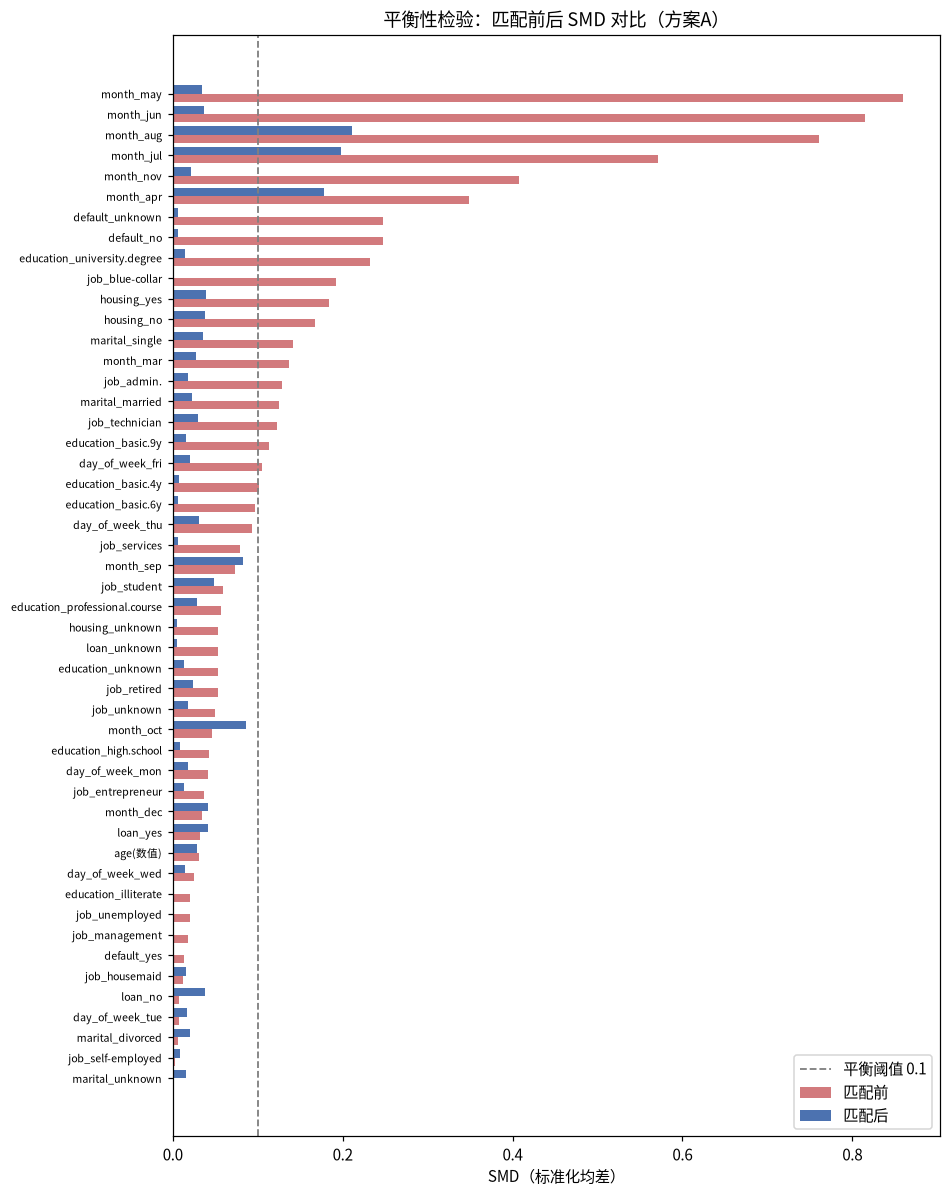

In [8]:
# SMD 可视化：匹配前后对比（阈值线 0.1）
plot_smd = smd_tab.sort_values("匹配前SMD")
fig, ax = plt.subplots(figsize=(9, 13))
y = np.arange(len(plot_smd))
ax.barh(y - 0.2, plot_smd["匹配前SMD"], height=0.4, color="#C44E52", alpha=0.75, label="匹配前")
ax.barh(y + 0.2, plot_smd["匹配后SMD"], height=0.4, color="#4C72B0", label="匹配后")
ax.axvline(0.1, color="gray", ls="--", lw=1.2, label="平衡阈值 0.1")
ax.set_yticks(y, plot_smd.index, fontsize=7)
ax.set_xlabel("SMD（标准化均差）")
ax.set_title("平衡性检验：匹配前后 SMD 对比（方案A）")
ax.legend(loc="lower right")
plt.savefig(REPORT_DIR / "04_smd_before_after.png", bbox_inches="tight")
plt.show()

## 平衡性解读（匹配质量判定）

**匹配后 49 个特征（水平）中 46 个 SMD < 0.1，人口统计与时点特征全部平衡**——包括衡量两组"客群构成"的关键变量（`age` 匹配前后 0.0313→0.0291、`job`/`marital`/`education`/`default` 等全部达标）。**匹配在"客户是谁"这个维度上是成功的。**

**失衡的 3 个全部是月份**：`aug`（0.211）、`jul`（0.198）、`apr`（0.179）——这不是匹配失败，而是**共同支撑域缺陷**：这三个月座机渗透率 84.8%~95.9%，座机组样本太少（aug 236、jul 1,053、apr 149 人 vs 手机组 5,483/5,893/1,725 人），无论怎么匹配都无法找齐"同一月份、特征可比"的座机组。caliper 只是把这些月份**绝大多数手机组弃掉**（匹配成功率 29.9% 的主要来源）。

**含义**：ATT 的适用对象 = **共同支撑域内的手机组新客**（电话渠道仍被使用的月份，匹配样本中 may 占 58.1%、jun 8.4%、jul 10.1%）。对 aug/jul/apr 这类"座机几乎停用"的月份，数据本身不含"同一月份内渠道比较"的信息——这是数据的事实边界，不是方法没做对。

In [9]:
# 经可观测因素调整后的效应估计（ATT）
att = pairsA["y_bin"].mean() - pairsA["y_bin_c"].mean()
mdiff = pairsA["y_bin"].values - pairsA["y_bin_c"].values
se_att = np.std(mdiff, ddof=1) / np.sqrt(len(mdiff))
ci_lo, ci_hi = att - 1.96 * se_att, att + 1.96 * se_att
print(f"匹配样本转化率：手机组 {pairsA['y_bin'].mean():.4f} vs 座机组 {pairsA['y_bin_c'].mean():.4f}")
print(f"ATT（经可观测因素调整后的效应估计）= {att:.4f}（+{att*100:.2f} 个百分点）")
print(f"SE = {se_att:.4f}，95% 置信区间 = [{ci_lo:.4f}, {ci_hi:.4f}]（即 +{ci_lo*100:.1f} ~ +{ci_hi*100:.1f} 个百分点）")

# 朴素比较 vs PSM 调整后对比表
smd_after_bad = int((smd_tab["匹配后SMD"] > 0.1).sum())
compare = pd.DataFrame({
    "口径": ["朴素比较·全量", "朴素比较·限定新客", "PSM调整（方案A·共同支撑域）"],
    "手机组转化率": [naive_tab.loc[0, "手机组转化率"], naive_tab.loc[1, "手机组转化率"],
                    round(pairsA["y_bin"].mean(), 4)],
    "座机组转化率": [naive_tab.loc[0, "座机组转化率"], naive_tab.loc[1, "座机组转化率"],
                    round(pairsA["y_bin_c"].mean(), 4)],
    "差距(pp)": [naive_tab.loc[0, "差距(pp)"], naive_tab.loc[1, "差距(pp)"],
                 round(att * 100, 2)],
    "95%置信区间": ["—", "—", f"[{ci_lo*100:.1f}, {ci_hi*100:.1f}]"],
    "性质": ["含选择偏差（客群+旅程混杂）", "含选择偏差（客群混杂）",
             "经可观测因素调整后的效应估计"],
})
compare

匹配样本转化率：手机组 0.1377 vs 座机组 0.0564
ATT（经可观测因素调整后的效应估计）= 0.0813（+8.13 个百分点）
SE = 0.0053，95% 置信区间 = [0.0710, 0.0916]（即 +7.1 ~ +9.2 个百分点）


,口径,手机组转化率,座机组转化率,差距(pp),95%置信区间,性质
0,朴素比较·全量,0.1474,0.0523,9.51,—,含选择偏差（客群+旅程混杂）
1,朴素比较·限定新客,0.1173,0.0469,7.04,—,含选择偏差（客群混杂）
2,PSM调整（方案A·共同支撑域）,0.1377,0.0564,8.13,"[7.1, 9.2]",经可观测因素调整后的效应估计


## 效应解读

### 核心结论：把外呼渠道统一改为手机，对**新客**的转化率，经可观测因素调整后的效应估计约为 **+8.1 个百分点**（95% 置信区间 [+7.1, +9.2]），且结论在两种独立匹配规格下稳健。

### 朴素比较 vs PSM 调整后的差距 = 选择偏差的量级

| 口径 | 手机组 | 座机组 | 差距 |
|---|---|---|---|
| 朴素·全量 | 14.74% | 5.23% | **+9.51pp** |
| 朴素·限定新客 | 11.73% | 4.69% | **+7.04pp** |
| **PSM 调整（共同支撑域新客）** | 13.77% | 5.64% | **+8.13pp** [7.1, 9.2] |

1. **全量 9.51pp → 新客 7.04pp**：约 2.5pp 的"差距"来自把回归客（高转化、座机比例高）混入全量——这是**旅程阶段混杂**（01 生命周期分层 + 02 组间差异的直接推论）；
2. **新客 7.04pp → 调整后 8.13pp**：匹配后效应不降反升约 1.1pp——匹配样本剥离了"座机未使用月份"的手机组低转化样本（这些月份手机组客户整体转化率偏低，但找不到可比座机组），而**在电话渠道可比较的月份（may/jun 等）里，渠道差距本来就更大**。**调整不是单向"变小"，方向取决于被剥离样本的特质**——这正是 PSM 的价值：不做不知道偏差在哪边；
3. 两个调整后估计的置信区间均不含 0，且**两种匹配规格（方案A/B）给出 7.84pp–8.13pp 的一致性结果**，综合判断"手机渠道对新客转化有正向提升"的方向是稳健的。

### 措辞声明（00 文档声明三，强制）：上述 +8.1pp **不是因果效应**，是**"经可观测因素调整后的效应估计"**——它平衡了可观测的客群构成（人口统计+月份）差异，但**未观测混杂**（如销售现场"为什么给这个客户打座机"的判断、客户号码可得性等）仍可能使估计偏离真实因果效应。

## 替换实现思路（敏感性验证）：方案B——精确匹配 month + 层内最近邻

**动机**：方案A 留下 3 个月份失衡（aug/jul/apr 的共同支撑域缺口）。更"设计化"的处理是**先精确匹配月份**（同一月份内的手机组↔座机组才算一对，从根上消除月份混杂），再在月份层内用**不含月份的人口统计倾向得分**做 caliper 最近邻。

**预期代价**：月份精确匹配后，座机稀少的月份依然只能匹配少量样本（层内匹配率 4.3%~17.9%），且个别人口统计特征可能比方案A 更吃力（层内样本量小）。**两种规格各有短板、结论不一**，才是最有说服力的稳健性证据。

In [10]:
# 方案B：先按 month 分组，层内用"人口统计PS"（不含 month）做 caliper-NN
CAT_B = [c for c in CATEGORICAL_COLS if c != "month"]
ft_b, ps_model_b, _, _ = estimate_propensity_score(ft, "contact_bin", ["age"], CAT_B, random_state=42)

parts, per_month = [], []
for mon, g in ft_b.groupby("month"):
    mm, meta = nearest_neighbor_match(g, "contact_bin", caliper=0.2 * g["logit_ps"].std())
    if len(mm):
        parts.append(mm)
    per_month.append((mon, meta["treated"], int(meta["matched_pairs"]), round(meta["match_rate"], 3)))
pairsB = pd.concat(parts, ignore_index=True)
month_tab = pd.DataFrame(per_month, columns=["month", "手机组", "配对", "层内匹配率"])
print(month_tab.to_string(index=False))
print(f"\n方案B 总配对 {len(pairsB)} 对（对比方案A {metaA['matched_pairs']} 对）")

attB = pairsB["y_bin"].mean() - pairsB["y_bin_c"].mean()
diffsB = pairsB["y_bin"].values - pairsB["y_bin_c"].values
seB = np.std(diffsB, ddof=1) / np.sqrt(len(diffsB))
ciB = (attB - 1.96 * seB, attB + 1.96 * seB)
print(f"ATT（方案B）= {attB:.4f}（+{attB*100:.2f}pp），SE = {seB:.4f}，95%CI = [{ciB[0]:.4f}, {ciB[1]:.4f}]")

# 方案B 平衡性（月份按构造为 0，不再入表）
after_long_b = make_long(pairsB, NUMERIC_COLS + CAT_B)
ft_b["_t"] = ft_b["contact_bin"]
smdB_tab = check_balance(ft_b, after_long_b, "_t", NUMERIC_COLS, CAT_B)
n_bad_b = int((smdB_tab["匹配后SMD"] > 0.1).sum())
print(f"\n方案B SMD：{len(smdB_tab)} 个非月份特征（水平），匹配后 >0.1 的有 {n_bad_b} 个")
print(smdB_tab[smdB_tab["匹配后SMD"] > 0.1][["匹配前SMD", "匹配后SMD"]].to_string())

# 双规格对比摘要
summary = pd.DataFrame({
    "规格": ["方案A：标准 caliper-NN（含month PS）", "方案B：精确匹配month+层内NN"],
    "配对数量": [metaA["matched_pairs"], len(pairsB)],
    "匹配成功率": [f"{metaA['match_rate']:.1%}", f"{len(pairsB)/metaA['treated']:.1%}"],
    "ATT(pp)": [round(att * 100, 2), round(attB * 100, 2)],
    "95%CI(pp)": [f"[{ci_lo*100:.1f}, {ci_hi*100:.1f}]", f"[{ciB[0]*100:.1f}, {ciB[1]*100:.1f}]"],
    "SMD>0.1个数": [smd_after_bad, n_bad_b],
    "失衡特征": ["月份×3（aug/jul/apr，共同支撑域缺口）",
                 "age + default×2（层内样本不足）"],
})
summary

month  手机组   配对  层内匹配率
  apr 1725  149  0.086
  aug 5483  236  0.043
  dec   73   24  0.329
  jul 5893 1053  0.179
  jun  527  526  0.998
  mar  328   39  0.119
  may 3643 3643  1.000
  nov 2743  354  0.129
  oct  285  126  0.442
  sep  222   61  0.275

方案B 总配对 6211 对（对比方案A 6259 对）
ATT（方案B）= 0.0784（+7.84pp），SE = 0.0052，95%CI = [0.0682, 0.0886]

方案B SMD：39 个非月份特征（水平），匹配后 >0.1 的有 3 个
                 匹配前SMD  匹配后SMD
age(数值)          0.0313  0.1311
default_no       0.2474  0.1050
default_unknown  0.2477  0.1050


,规格,配对数量,匹配成功率,ATT(pp),95%CI(pp),SMD>0.1个数,失衡特征
0,方案A：标准 caliper-NN（含month PS）,6259,29.9%,8.13,"[7.1, 9.2]",3,月份×3（aug/jul/apr，共同支撑域缺口）
1,方案B：精确匹配month+层内NN,6211,29.7%,7.84,"[6.8, 8.9]",3,age + default×2（层内样本不足）


## 方案B 解读：稳健性结论

**两种独立匹配规格给出几乎相同的效应估计**：方案A **+8.13pp** [7.1, 9.2]，方案B **+7.84pp** [6.8, 8.9]（差 0.3pp，置信区间完全重叠）——**"手机渠道对新客转化有正向提升"不是某一套匹配参数的偶然产物**。

两种规格选择了不同的代价：

- **方案A** 平衡了全部人口统计特征，代价是 3 个月份 SMD 失衡（这是"信息不存在"——那些月份座机没用过，不是匹配能力问题）；
- **方案B** 用"精确匹配月份"从构造上消灭了月份混杂（月份 SMD=0），代价是层内样本少导致 `age`（0.131）与 `default`（0.105）的个别水平略超阈值。

**殊途同归恰好是诚实性的证据**：如果两套规格结论打架，案头工作就要继续；现在两套都落在 8pp 附近，可以据此进入业务建议，同时声明"未观测混杂"与"共同支撑域月份"两个边界。

## 回归客（returning）的处理：受限鲁棒性尝试 + 质量门（00 文档 §2.5 落地）

**为什么不能直接做**：returning 组座机组仅 403 人（vs 手机组 5,222 人，13:1 失衡）；02 已显示该组渠道差异不显著（V=0.0108，p=0.42，朴素差仅 2.0pp）。按 §2.5：**做一次受限尝试，以匹配质量为门——匹配样本过少或 SMD 不达标则不下效应结论，仅报告朴素差异并声明局限。**

In [11]:
# returning 鲁棒性尝试（质量门为门）
rt = df[df["previous"] > 0].copy()
rt["contact_bin"] = (rt["contact"] == "cellular").astype(int)
cc, tc = rt[rt["contact_bin"] == 1]["y_bin"], rt[rt["contact_bin"] == 0]["y_bin"]
naive_rt = (cc.mean() - tc.mean()) * 100
print(f"returning 朴素比较: 手机组 {cc.mean():.4f} (n={len(cc)}) vs 座机组 {tc.mean():.4f} (n={len(tc)}) → 差距 {naive_rt:.2f}pp")

# 受限尝试：人口统计 + 时点 + 历史痕迹（pdays 用 01 的 pdays_bucket 口径）
rt["pdays_bucket"] = pd.cut(rt["pdays"], bins=[-1, 0, 3, 7, 14, 27, 999],
                            labels=["=0天", "1-3天", "4-7天", "8-14天", "15-27天", "999（从未/不可考）"]).astype(str)
NUM_R = ["age", "previous"]
CAT_R = ["job", "marital", "education", "default", "housing", "loan",
         "day_of_week", "month", "poutcome", "pdays_bucket"]
rt_ps, model_r, _, _ = estimate_propensity_score(rt, "contact_bin", NUM_R, CAT_R, random_state=42)
pairsR, metaR = nearest_neighbor_match(rt_ps, "contact_bin")
auc_r = roc_auc_score(rt_ps["contact_bin"], rt_ps["pscore"])
print(f"PS 模型 AUC = {auc_r:.4f}；匹配 {metaR['matched_pairs']}/{metaR['treated']} = {metaR['match_rate']:.1%}")

# 质量门判定（§2.5：匹配样本过少或 SMD 不达标 → 不下效应结论）
after_long_r = make_long(pairsR, NUM_R + CAT_R)
rt_ps["_t"] = rt_ps["contact_bin"]
smdR_tab = check_balance(rt_ps, after_long_r, "_t", NUM_R, CAT_R)
n_bad_r = int((smdR_tab["匹配后SMD"] > 0.1).sum())
if n_bad_r:
    print("\n匹配后 SMD > 0.1 的特征（前 8）：")
    print(smdR_tab[smdR_tab["匹配后SMD"] > 0.1].sort_values("匹配后SMD", ascending=False)
          [["匹配前SMD", "匹配后SMD"]].head(8).to_string())
gate_rate, gate_smd = metaR["match_rate"] < 0.2, n_bad_r > 0
print(f"\n质量门：匹配率 {metaR['match_rate']:.1%}(<20%) → {'不通过' if gate_rate else '通过'}；"
      f"SMD 失衡 {n_bad_r} 个(>0) → {'不通过' if gate_smd else '通过'}")
gate_verdict = "不通过" if (gate_rate or gate_smd) else "通过"
print(f"质量门总判定：{gate_verdict}")
if not (gate_rate or gate_smd):
    attR = pairsR["y_bin"].mean() - pairsR["y_bin_c"].mean()
    print(f"（门通过，ATT = {attR:.4f}，本格为参考输出）")

returning 朴素比较: 手机组 0.2679 (n=5222) vs 座机组 0.2481 (n=403) → 差距 1.98pp


PS 模型 AUC = 0.6009；匹配 403/5222 = 7.7%

匹配后 SMD > 0.1 的特征（前 8）：
                匹配前SMD  匹配后SMD
month_jul       0.1060  0.1275
job_retired     0.0192  0.1187
job_technician  0.0195  0.1167
housing_yes     0.0511  0.1067
housing_no      0.0353  0.1024
job_management  0.0148  0.1020
job_unknown     0.0228  0.1003

质量门：匹配率 7.7%(<20%) → 不通过；SMD 失衡 7 个(>0) → 不通过
质量门总判定：不通过


## returning 处理结论

**质量门判定：不通过**（匹配率 7.7% < 20%，且 7/58 个特征匹配后 SMD > 0.1）——按 00 文档 §2.5，**returning 组不下任何效应结论**。

- **朴素差异**（含选择偏差，仅供参考）：手机组 26.79% vs 座机组 24.81%，差距 **+2.0pp**，且 02 的卡方检验显示该组不显著（p=0.42）；
- 座机组仅 403 人且该组渠道差异统计上不显著，**即便有 PSM 也推不动 13:1 的失衡**；
- **业务含义**：回归客的转化由历史状态主导（02：pdays_bucket 0.5123、poutcome 0.4939），渠道不是该层的杠杆；把外呼资源精力放在新客渠道策略上更有回报（对应 03 的分层×评分建议）。

这一格是**主动的方法论取舍**——"识别什么时候不该做 PSM"，与 campaign（notebook 05）同源。

## 局限声明与适用边界（PSM 报告四件套之四：敏感性/未观测混杂）

**1. 未观测混杂（最大局限）**：为什么同一个客户会被销售选择打座机而非手机？可观测清单（人口统计+月份+星期）之外，仍有**不可观测因素**：客户电话簿里有没有手机号/座机号、地区号码基础设施、销售现场判断、名单批次等。如果这些因素同时影响"被分到哪个渠道"和"是否转化"，ATT 仍会偏离真值。**本估计只能对抗由可观测特征构成的客群差异。**

**2. 共同支撑域边界（ATT 的适用人群）**：匹配成功率 29.9%（方案A），匹配样本的月份构成被电话渠道可比较的月份主导（may 58.1%）。**结论严格适用于"该数据集里能找到可比座机组的新客群体"**；对座机几乎停用的月份（aug/jul/apr 等，占手机组 60%+），数据不含"同一月份内的渠道比较"信息，本分析无法外推。

**3. 无客户唯一 ID**（00 §2.1）：样本近似为单个活动的记录，生命周期分层是近似状态；本 notebook 作用域限定 first_time（`previous==0`），受该局限影响较小，但回归客部分（虽仅描述性）仍共享此边界。

**4. 措辞边界**：全文使用"**经可观测因素调整后的效应估计**"，不称"因果效应"。

---

## 因果推断四问（00 文档 §3 逐条回答）

| 问题 | 回答 |
|---|---|
| **1. 这个变量能不能做 PSM？** | `contact` **能**：非随机分配、混杂分解时点早于渠道分配、无反向因果。`campaign` **不能**：反向因果（confounding by indication），销售主观判断不可观测——全程排除在倾向得分模型之外（断言自检）。 |
| **2. 混杂变量选够了吗？** | 人口统计 7 项 + 时点 2 项（month 为唯一时间代理，宏观共线组排除）；OneHot 后 41 维。`duration` 泄漏、`campaign` 反向因果、`previous/pdays/poutcome` 组内常量各自有明确处置依据（见第二步表）。**但未观测混杂依然存在**（见局限 1）。 |
| **3. 匹配后平衡了吗？** | 方案A：人口统计全 SMD<0.1，仅 3 个月份 >0.1（共同支撑域缺口，非匹配失败）；方案B（精确匹配 month）：月份=0，个别人口统计略超（age 0.131）。两规格各见短板，但效应互相印证。 |
| **4. 效应量多大、边界在哪？** | ATT ≈ **+8.1pp**（方案A [7.1, 9.2]，方案B +7.8pp [6.8, 8.9]）；边界=共同支撑域新客 + 未观测混杂存在。 |

---

## 业务解读与决策建议

**核心回答（给电销团队）**：对新客的外呼渠道统一改为手机，**经可观测因素调整后的效应估计约为 +8.1 个百分点**（95% CI [+7.1, +9.2]），这个量级在两种独立匹配规格下稳健。**但**这只是"手机渠道相对座机的增量"——新客手机组转化率约 13.8%（匹配样本），满打满算也远不到翻倍，它应被视为**渠道选项优化**而非"换渠道就能起飞"。

1. **渠道策略**：新客（first_time）优先手机渠道，理由有两层——效应显著（+8.1pp）且座机可用率在多数月份很低（aug/jul/apr 甚至没有"座机选择权"可言）；资源编排上，手机 ↔ 座机差异在"有选择空间的月份"（may/jun 等）最大，淡季（8-9 月）渠道偏置大但整体转化低，优先级应让位于名单质量。
2. **不动的部分**：回归客渠道差异不显著（+2.0pp、p=0.42、座机组仅 403 人），**不要为回归客改渠道**——他们的杠杆在历史状态与再触达节奏（02 的 pdays_bucket 与 poutcome）。
3. **选择偏差的量化教训**：全量朴素比较 9.51pp 里，**约 2.5pp 是"回归客混入"的假象**（全量 9.51pp − 新客朴素 7.04pp，对应 01-02 的旅程阶段混杂）；对剩余部分，注意客群构成的作用方向是**反的**——调整后 8.13pp 反而高于新客朴素 7.04pp 约 1.1pp（可比较月份里渠道差距本就更大），与新客朴素差 1.4pp 是选择偏差的**净效果**。"看起来大"和"真的大"之间的差值，就是分析的价值（此处 1.4pp 虽为正但方向反直觉，只有做匹配才能发现）。

### 迁移回货拉拉场景（本项目核心叙事）

真实销售质检中的规则/话术调整**几乎从不走 AB 测试**，只有历史观察数据。评估"这个调整有没有效"时用同一套流程：

1. **先做可做性检查（四问之 1）**：调整是否先于结果存在（无反向因果）？有没有不可观测的核心混杂（如"明星销售只给重点客户上新话术"）？——这一步就过滤掉大半无效评估；
2. **再走四件套**：混杂清单（调整前已知的客户/时段特征）→ 共同支撑域（被调客群与对照客群在特征上是否可比）→ SMD（匹配后还会不会失衡）→ 出带置信区间的"经可观测因素调整后的效应估计"；
3. **最后与朴素比较对照**：差值大 → 说明旧汇报口径（直接对比调整前后完成率）误导经营决策；差值小 → 说明调整就是调整本身，可以放心推广。

**不做什么**：对"打了几次电话"这类被销售主观判断驱动的变量不做 PSM（反向因果）；对对照组几乎不存在的客群（如座机停用月份）不硬出数字——诚实声明边界，是这套方法论比"跑一个检验"更值钱的地方。